In [92]:
import json

# 假设你的文件名是data.json
file_path = '/p/lustre2/shan4/Fuzzlang/log_llvm_remove3.json'
# 初始化一个空列表来存储所有的JSON对象
json_objects = []

# 打开文件并逐行读取
with open(file_path, 'r', encoding='utf-8') as file:
    i = 1
    for line in file:
        # 解析每一行的JSON对象
        try:
            json_object = json.loads(line.strip())
        except:
            continue
        # 将解析的对象添加到列表中
        json_objects.append(json_object)
        i += 1
success = [i for i in json_objects if i['status']=='SUCCESS' ]
print(len(success))
failed = [i for i in json_objects if i['status']=='ERROR' ]
print(len(failed))

2895
6


In [9]:
def count_lines_in_file(file_path):
    try:
        with open(file_path, 'r') as file:
            lines = file.readlines()
            line_count = len(lines)
        return line_count
    except FileNotFoundError:
        return "File not found. Please check the file path."

# Replace 'your_file.txt' with the path to your text file
file_path = '../log_llvm_removept3.json'
line_count = count_lines_in_file(file_path)
print(f"The file '{file_path}' has {line_count} lines.")

The file '../log_llvm_removept3.json' has 17240 lines.


In [1]:
import clang.cindex

def list_cursor_kinds():
    kinds = []
    for kind in clang.cindex.CursorKind.get_all_kinds():
        kinds.append((kind, kind.name, kind.value))
    return kinds

if __name__ == "__main__":
    cursor_kinds = list_cursor_kinds()
    for kind, name, value in cursor_kinds:
        print(f"Kind: {kind}, Name: {name}, Value: {value}")

Kind: CursorKind.UNEXPOSED_DECL, Name: UNEXPOSED_DECL, Value: 1
Kind: CursorKind.STRUCT_DECL, Name: STRUCT_DECL, Value: 2
Kind: CursorKind.UNION_DECL, Name: UNION_DECL, Value: 3
Kind: CursorKind.CLASS_DECL, Name: CLASS_DECL, Value: 4
Kind: CursorKind.ENUM_DECL, Name: ENUM_DECL, Value: 5
Kind: CursorKind.FIELD_DECL, Name: FIELD_DECL, Value: 6
Kind: CursorKind.ENUM_CONSTANT_DECL, Name: ENUM_CONSTANT_DECL, Value: 7
Kind: CursorKind.FUNCTION_DECL, Name: FUNCTION_DECL, Value: 8
Kind: CursorKind.VAR_DECL, Name: VAR_DECL, Value: 9
Kind: CursorKind.PARM_DECL, Name: PARM_DECL, Value: 10
Kind: CursorKind.OBJC_INTERFACE_DECL, Name: OBJC_INTERFACE_DECL, Value: 11
Kind: CursorKind.OBJC_CATEGORY_DECL, Name: OBJC_CATEGORY_DECL, Value: 12
Kind: CursorKind.OBJC_PROTOCOL_DECL, Name: OBJC_PROTOCOL_DECL, Value: 13
Kind: CursorKind.OBJC_PROPERTY_DECL, Name: OBJC_PROPERTY_DECL, Value: 14
Kind: CursorKind.OBJC_IVAR_DECL, Name: OBJC_IVAR_DECL, Value: 15
Kind: CursorKind.OBJC_INSTANCE_METHOD_DECL, Name: OBJC_I

In [86]:
print(failed[10]['fuzzed_args'])

['-c', '-fno-exceptions', '-D_GNU_SOURCE', '-o lib/Support/CMakeFiles/LLVMSupport.dir/Base64.cpp.o', '-Wctad-maybe-unsupported', '-Wnon-virtual-dtor', '-Werror=global-constructors', '-Wdelete-non-virtual-dtor', '-Wstring-conversion', '-I/p/lustre2/shan4/llvm-project/llvm/lib/Support']


In [85]:
print(failed[10]['message'])

/opt/rh/gcc-toolset-12/root/usr/lib/gcc/x86_64-redhat-linux/12/../../../../bin/ld: /lib/../lib64/Scrt1.o: in function `_start':
(.text+0x24): undefined reference to `main'
/opt/rh/gcc-toolset-12/root/usr/lib/gcc/x86_64-redhat-linux/12/../../../../bin/ld: /var/tmp/shan4/Base64-54ab22.o: in function `llvm::createStringError(std::error_code, char const*)':
Base64.cpp:(.text._ZN4llvm17createStringErrorESt10error_codePKc[_ZN4llvm17createStringErrorESt10error_codePKc]+0xa2): undefined reference to `llvm::createStringError(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >&&, std::error_code)'
/opt/rh/gcc-toolset-12/root/usr/lib/gcc/x86_64-redhat-linux/12/../../../../bin/ld: /var/tmp/shan4/Base64-54ab22.o: in function `llvm::Error llvm::createStringError<char, unsigned long>(std::error_code, char const*, char const&, unsigned long const&)':
Base64.cpp:(.text._ZN4llvm17createStringErrorIJcmEEENS_5ErrorESt10error_codePKcDpRKT_[_ZN4llvm17createStringErrorIJcmEEENS_5E

In [15]:
import multiprocessing
import json
import re
import glob
import os


errs = []


def escape_special_chars(text):
    return re.sub(r'([.^$+?{}[\]\\()])', r'\\\1', text)


def escape_special_chars_diff(text):
    return re.sub(r'([.*^+?{}[\]\\()])', r'\\\1', text)


def escape_special_chars1(text):
    return re.sub(r'([.^$*+|?{}[\]\\()])', r'\\\1', text)


def escape_special_chars_select(text):
    return re.sub(r'([.^$*+?{}[\]\\()])', r'\\\1', text)


def process_plural_segment(segment):
    plural_pattern = re.compile(r'%plural\{([^}]*)\}\d')
    match = plural_pattern.match(segment)
    if not match:
        return escape_special_chars(segment)

    content = match.group(1)
    forms = [part.split(':', 1)[1] for part in content.split('|')]
    formatted_content = '|'.join(forms)
    return f'({escape_special_chars(formatted_content)})'


def remove_comments(input_string):
    return re.sub(r'//.*?\n', '\n', input_string)


def find_matching_brace(s, start):
    count = 1
    for i in range(start + 1, len(s)):
        if s[i] == '{':
            count += 1
        elif s[i] == '}':
            count -= 1
        if count == 0:
            return i
    return -1


def process_diff(input_string, start):
    content_start = input_string.index('{', start) + 1
    content_end = find_matching_brace(input_string, content_start - 1)
    if content_end == -1:
        raise ValueError("Unmatched brace in select")

    content = input_string[content_start:content_end]
    processed_content = process_diff_content(content)

    number_end = content_end + 3
    while number_end < len(input_string) and input_string[number_end].isdigit():
        number_end += 1
    processed_content = processed_content.replace('$', '.*')
    return f'({processed_content})', number_end


def process_diff_content(content):
    parts = re.split(r'(%select\{[^}]*\}\d*)', content)
    processed_parts = []
    for part in parts:
        if part.startswith('%select'):
            diff_pattern = re.compile(r'%select\{([^}]*)\}\d*')
            match = diff_pattern.match(part)
            if match:
                diff_content = match.group(1)
                processed_parts.append(
                    f'({escape_special_chars_select(diff_content).replace("$", ".*")})')
        else:
            processed_parts.append(escape_special_chars_diff(part))
    return ''.join(processed_parts)


def process_select(input_string, start):
    content_start = input_string.index('{', start) + 1
    content_end = find_matching_brace(input_string, content_start - 1)
    if content_end == -1:
        raise ValueError("Unmatched brace in select")

    content = input_string[content_start:content_end]
    processed_content = process_select_content(content)

    number_end = content_end + 1
    while number_end < len(input_string) and input_string[number_end].isdigit():
        number_end += 1

    return f'({processed_content})', number_end


def process_select_content(content):
    def process_nested(nested_content):
        nested_parts = re.split(r'(%select\{[^}]*\}\d*|%diff\{[^}]*\}\d,\d*)', nested_content)
        processed_nested_parts = []
        for nested_part in nested_parts:
            if nested_part.startswith('%select'):
                select_pattern = re.compile(r'%select\{([^}]*)\}\d*')
                match = select_pattern.match(nested_part)
                if match:
                    select_content = match.group(1)
                    processed_nested_parts.append(f'({process_nested(select_content)})')
            elif nested_part.startswith('%diff'):
                diff_pattern = re.compile(r'%diff\{([^}]*)\}\d,\d*')
                match = diff_pattern.match(nested_part)
                if match:
                    diff_content = match.group(1)
                    processed_nested_parts.append(
                        f'({escape_special_chars_diff(diff_content).replace("$", ".*")})')
            else:
                part = escape_special_chars_select(nested_part)
                part = re.sub(r'%\d', '.*', part)
                processed_nested_parts.append(part)
        return ''.join(processed_nested_parts)

    return process_nested(content)


def process_string(input_string):
    input_string = remove_comments(input_string)
    result = []
    index = 0

    while index < len(input_string):
        match_found = False

        if input_string.startswith('%select', index):
            processed_select, new_index = process_select(input_string, index)
            result.append(processed_select)
            index = new_index
            match_found = True

        if input_string.startswith('%diff', index):
            processed_select, new_index = process_diff(input_string, index)
            result.append(processed_select)
            index = new_index
            match_found = True

        if not match_found:
            for pattern, output in [
                (re.compile(r'%s\d+'), '.*'),
                (re.compile(r'%ordinal\d+'), '.*'),
                (re.compile(r'%q\d+'), '.*'),
                (re.compile(r'%sub\{([^}]*)\}(?:\d,)*\d'), '.*'),
                (re.compile(r'%plural\{([^}]*)\}\d'),
                 lambda m: process_plural_segment(m.group(0))),
                (re.compile(r'%\d'), '.*'),
            ]:
                match = pattern.match(input_string, index)
                if match:
                    if isinstance(output, str):
                        result.append(output)
                    else:
                        result.append(output(match))
                    index = match.end()
                    match_found = True
                    break

        if not match_found:
            result.append(escape_special_chars1(input_string[index]))
            index += 1

    res = ''.join(result).replace('"', '').replace('\n', '')
    return res


def extract_errors_from_td(file_path):
    errors = {}
    with open(file_path, 'r') as file:
        content = file.read()
        pattern = r'def\s+(\w+)\s*:\s*Error\s*<(.*?)>(,|;)'

        matches = re.finditer(pattern, content, re.DOTALL)
        for match in matches:
            error_name = match.group(1)
            error_message = match.group(2)
            error_message = re.sub(r'(?m)^\s+', '', error_message)
            error_message = remove_comments(error_message)
            error_message = re.sub(r'(?<!\\)"', '', error_message)
            error_message = re.sub(r'\\n|\n|\r|\t', '', error_message)
            error_message = re.sub(r'\s+', ' ', error_message)
            error_message = error_message.strip()
            error_message = process_string(error_message)
            errors[error_name] = error_message
    return errors


def process_message(message, errors):
    process_name = multiprocessing.current_process().name
    for error_name, error_pattern in errors.items():
        if error_pattern == ".*":
            continue
        if error_pattern == "err_diagnose_if_succeeded":
            continue
        try:
            if re.match(error_pattern, message):
                return (message, error_name)
        except:
            print(f"original: {error_pattern}")
            print(f"error_name: {error_name}")
            return (message, None)
    return (message, None)


def match_error_messages_parallel(errors, messages):
    matched = {}
    notfound = []
    matched['not_found'] = 0

    with multiprocessing.Pool(processes=56) as pool:
        results = pool.starmap(
            process_message, [(message, errors) for message in messages])

    for message, result in results:
        if result:
            if result in matched:
                matched[result] += 1
            else:
                matched[result] = 1
        else:
            notfound.append(message)
            matched['not_found'] += 1

    return matched, notfound


def match_error_messages(errors, messages):
    matched = {}
    notfound = []
    matched['not_found'] = 0
    for message in messages:
        for error_name, error_pattern in errors.items():
            if error_pattern == ".*":
                continue
            if error_pattern == "err_diagnose_if_succeeded":
                continue
            try:
                if re.match(error_pattern, message):
                    if error_name in matched:
                        matched[error_name] += 1
                    else:
                        matched[error_name] = 1
                    # print(f"pattern: {pattern}")
                    # print(f"message: {message}")
                    break
            except:
                # print(f"falied! pattern is :{pattern}")
                print(f"original: {error_pattern}")
                print(f"error_name: {error_name}")
                print(process_string(error_pattern))
                return
        else:
            notfound.append(message)
            matched['not_found'] += 1
    return matched, notfound


def remove_ansi_escape_sequences(text):
    ansi_escape = re.compile(r'\x1B\[[0-?]*[ -/]*[@-~]')
    return ansi_escape.sub('', text)


def extract_errors(text):
    error_pattern = re.compile(r':\s+error:\s+(.*?)(?=\n)', re.DOTALL)
    errors = error_pattern.findall(text)

    return errors

def process_json(file_name):
    errs = []
    with open(file_name, 'r') as file:
        for line in file:
            data = json.loads(line)
            errs.append(data)
    return errs

def main():
    all_errors = {}
    for td_file in glob.glob('../tdfile/*.td'):
        all_errors.update(extract_errors_from_td(td_file))
        
    errors = []
    
    err_messages = []
    
    def get_json_files(folder_path):
        return [os.path.join(folder_path, file) for file in os.listdir(folder_path) if file.endswith('.json')]
    jsonfiles = get_json_files('../.json')
    for file_name in jsonfiles:
        print(file_name)
        err_messages.extend(process_json(file_name))
    # file_name = "../.json/error_log_llvm.json"
    # err_messages.extend(process_json(file_name))
    # file_name = "../.json/error_log_llvm1.json"
    # err_messages.extend(process_json(file_name))
    # file_name = "../.json/error_log_llvm6.json"
    # err_messages.extend(process_json(file_name))
    # file_name = "../.json/error_log_llvm5.json"
    # err_messages.extend(process_json(file_name))
    for i in err_messages:
        str_tmp = i['message']
        str_tmp = remove_ansi_escape_sequences(str_tmp)
        errors.extend(extract_errors(str_tmp))
    results, notfound = match_error_messages_parallel(all_errors, errors)
    
    
    
    with open('notfound3.list', 'w') as file:
        for element in notfound:
            file.write(f"{element}\n")
    print(len(results))
    #print(results)
    filename = 'error_type3.json'

    with open(filename, 'w') as json_file:
        json.dump(results, json_file, indent=4)



In [16]:
all_errors = {}
for td_file in glob.glob('../tdfile/*.td'):
    all_errors.update(extract_errors_from_td(td_file))

In [51]:
filter = ['hip', 'cuda', 'omp', 'cuda', 'acc', 'Microsoft', 'objc','ObjC', 'microsoft', 'mips', 'aarch64', 'ppe','_ms', '_amd', 'apple','macos','_arm']
def filter_errors(all_errors, filter):
    errors = {}
    filter_lower = [x.lower() for x in filter] 
    for key, value in all_errors.items():
        key_lower = key.lower() 
        value_lower = value.lower()
        if any(x in key_lower for x in filter_lower):
            continue
        errors[key] = value
    return errors
filtered_errors = filter_errors(all_errors, filter)
len(filtered_errors)

2801

In [48]:
x = list(merged_dict.keys())
e = []
for error in filtered_errors:
    if error not in x:
        e.append(error)
e[522:1000]

['err_invalid_vector_double_decl_spec',
 'err_invalid_vector_bool_int128_decl_spec',
 'err_invalid_vector_int128_decl_spec',
 'err_invalid_vector_long_long_decl_spec',
 'err_invalid_vector_long_double_decl_spec',
 'err_bad_parameter_name',
 'err_anyx86_interrupt_attribute',
 'err_anyx86_interrupt_called',
 'err_arm_interrupt_called',
 'err_ellipsis_first_param',
 'err_language_linkage_spec_unknown',
 'err_noreturn_non_function',
 'err_std_type_trait_not_class_template',
 'err_using_typename_non_type',
 'err_using_dependent_value_is_type',
 'err_using_decl_nested_name_specifier_is_current_class',
 'err_using_decl_nested_name_specifier_is_not_base_class',
 'err_using_decl_constructor_not_in_direct_base',
 'err_using_decl_can_not_refer_to_class_member',
 'err_using_enum_is_dependent',
 'err_using_enum_not_enum',
 'err_ambiguous_inherited_constructor',
 'err_using_decl_can_not_refer_to_namespace',
 'err_using_decl_constructor',
 'err_using_decl_destructor',
 'err_using_decl_template_id',
 

In [117]:
def get_line_at_offset(content, offset):
    start = content.rfind('\n', 0, offset) + 1
    end = content.find('\n', offset)
    if end == -1:
        end = len(content)

    # Check for line continuation
    while content[end-1] == '\\':
        next_end = content.find('\n', end + 1)
        if next_end == -1:
            end = len(content)
            break
        end = next_end

    return content[start:end]

In [58]:
with open("../tmp.cpp", 'r') as file:
        content = file.read()
get_line_at_offset(content, 230)


'void func(){'

In [80]:
get_declaration_at_offset("../tmp.cpp", 220)

In [1]:
import clang.cindex


def print_ast(node, indent=0):
    print('  ' * indent + str(node.kind), node.spelling)
    for child in node.get_children():
        print_ast(child, indent + 1)


if not clang.cindex.Config.library_file:
    clang.cindex.Config.set_library_file(
        '/p/lustre2/shan4/llvm-trunk/lib/libclang.so')
    
    
index = clang.cindex.Index.create()


cpp_code = """
struct tttt{
    int a;
    int b;
};

int main() {
    struct tttt ccc;
    tttt ccc;
    return 0;
}
"""
tu = index.parse('temp.c', unsaved_files=[('temp.c', cpp_code)])

print_ast(tu.cursor)

CursorKind.TRANSLATION_UNIT temp.c
  CursorKind.STRUCT_DECL tttt
    CursorKind.FIELD_DECL a
    CursorKind.FIELD_DECL b
  CursorKind.FUNCTION_DECL main
    CursorKind.COMPOUND_STMT 
      CursorKind.DECL_STMT 
        CursorKind.VAR_DECL ccc
          CursorKind.TYPE_REF struct tttt
      CursorKind.DECL_STMT 
        CursorKind.VAR_DECL ccc
          CursorKind.TYPE_REF struct tttt
      CursorKind.RETURN_STMT 
        CursorKind.INTEGER_LITERAL 


In [3]:
import clang.cindex

def get_cursor_kind_name(kind):
    return str(kind).split('.')[-1]

def find_parentheses(node, filename, source):
    if node.location.file and node.location.file.name != filename:
        return

    if node.kind == clang.cindex.CursorKind.CALL_EXPR or node.kind == clang.cindex.CursorKind.FUNCTION_DECL:
        start = node.extent.start.offset
        end = node.extent.end.offset
        content = source[start:end]
        
        # 查找左括号的位置
        left_paren_pos = content.find('(')
        if left_paren_pos != -1:
            abs_left_paren_pos = start + left_paren_pos
            print(f"Left parenthesis at position {abs_left_paren_pos}, type: {get_cursor_kind_name(node.kind)}")

        # 查找右括号的位置
        right_paren_pos = content.rfind(')')
        if right_paren_pos != -1:
            abs_right_paren_pos = start + right_paren_pos
            print(f"Right parenthesis at position {abs_right_paren_pos}, type: {get_cursor_kind_name(node.kind)}")

    for child in node.get_children():
        find_parentheses(child, filename, source)

def main():
    index = clang.cindex.Index.create()
    
    # 替换为您的C/C++文件路径
    file_path = 'tmp.cpp'
    
    with open(file_path, 'r') as file:
        source = file.read()

    tu = index.parse(file_path)
    
    if not tu:
        print("Failed to parse the source file.")
        return

    find_parentheses(tu.cursor, file_path, source)

if __name__ == "__main__":
    main()

Left parenthesis at position 25, type: FUNCTION_DECL
Right parenthesis at position 26, type: FUNCTION_DECL
Left parenthesis at position 90, type: FUNCTION_DECL
Right parenthesis at position 240, type: FUNCTION_DECL
Left parenthesis at position 102, type: CALL_EXPR
Right parenthesis at position 103, type: CALL_EXPR
Left parenthesis at position 116, type: CALL_EXPR
Right parenthesis at position 124, type: CALL_EXPR
Left parenthesis at position 137, type: CALL_EXPR
Right parenthesis at position 145, type: CALL_EXPR
Left parenthesis at position 158, type: CALL_EXPR
Right parenthesis at position 166, type: CALL_EXPR
Left parenthesis at position 179, type: CALL_EXPR
Right parenthesis at position 187, type: CALL_EXPR
Left parenthesis at position 200, type: CALL_EXPR
Right parenthesis at position 208, type: CALL_EXPR
Left parenthesis at position 218, type: CALL_EXPR
Right parenthesis at position 219, type: CALL_EXPR
Left parenthesis at position 232, type: CALL_EXPR
Right parenthesis at positio

In [6]:
from clang.cindex import CursorKind

def print_cursor_kinds():
    for attr in dir(CursorKind):
        if not attr.startswith("__"):  # 过滤掉内置属性
            value = getattr(CursorKind, attr)
            if isinstance(value, CursorKind):
                print(f"{attr}: {value}")

In [12]:
import clang.cindex
from clang.cindex import CursorKind, TokenKind

def get_cursor_kind_name(kind):
    return str(kind).split('.')[-1]

def find_parenthesis_attribute(tu, file_path, line, column):
    def get_cursor_at_location(cursor, line, column):
        if (cursor.location.file and 
            cursor.location.file.name == file_path and
            cursor.extent.start.line <= line <= cursor.extent.end.line and
            cursor.extent.start.column <= column <= cursor.extent.end.column):
            
            for child in cursor.get_children():
                result = get_cursor_at_location(child, line, column)
                if result:
                    return result
            return cursor
        return None

    cursor = get_cursor_at_location(tu.cursor, line, column)
    if not cursor:
        return "No cursor found at the specified location."

    # 检查是否确实是括号
    for token in cursor.get_tokens():
        if (token.location.line == line and 
            token.location.column == column and 
            token.kind == TokenKind.PUNCTUATION and 
            token.spelling in '()'):
            break
    else:
        return "No parenthesis found at the specified location."

    # 向上遍历AST找到最近的有意义的父节点
    while cursor and cursor.kind in [CursorKind.UNEXPOSED_EXPR, CursorKind.DECL_REF_EXPR]:
        cursor = cursor.semantic_parent

    if not cursor:
        return "Could not determine the context of the parenthesis."

    return f"Parenthesis at {file_path}:{line}:{column} is part of a {get_cursor_kind_name(cursor.kind)}"

def main():
    index = clang.cindex.Index.create()
    
    # 替换为您的C/C++文件路径
    file_path = 'tmp.cpp'
    
    tu = index.parse(file_path)
    
    if not tu:
        print("Failed to parse the source file.")
        return

    # 替换为您知道的括号位置
    line = 10
    column = 15

    result = find_parenthesis_attribute(tu, file_path, line, column)
    print(result)

if __name__ == "__main__":
    main()

No cursor found at the specified location.


In [ ]:
import json

In [8]:
import json

# 读取JSON文件并加载到字典中
def read_json(file_path):
    with open(file_path, 'r') as f:
        return json.load(f)

# 合并两个字典，对于相同的键，将值相加
def merge_dicts(dict1, dict2):
    merged_dict = dict1.copy()
    for key, value in dict2.items():
        if key in merged_dict:
            merged_dict[key] += value
        else:
            merged_dict[key] = value
    return merged_dict

# 文件路径
file1 = 'error_type.json'
file2 = 'error_type1.json'
file3 = 'error_type2.json'
file4 = 'error_type3.json'
# 读取文件
dict1 = read_json(file1)
dict2 = read_json(file2)
dict3 = read_json(file3)
dict4 = read_json(file4)
# 合并字典
merged_dict = merge_dicts(dict1, dict2)
merged_dict = merge_dicts(merged_dict, dict3)
merged_dict = merge_dicts(merged_dict, dict4)
# 输出合并后的字典
#print(json.dumps(merged_dict, indent=4))
len(merged_dict)

433

In [9]:
merged_dict

{'not_found': 122,
 'err_invalid_token_after_toplevel_declarator': 3190,
 'err_expected_semi_declaration': 6220,
 'err_expected_unqualified_id': 7235,
 'err_typecheck_call_not_function': 387,
 'err_expected': 11501,
 'err_missing_param': 103,
 'err_ovl_diff_return_type': 74,
 'err_member_decl_does_not_match': 7554,
 'err_typecheck_call_too_many_args': 370,
 'err_undeclared_var_use': 49497,
 'err_lvalue_reference_bind_to_unrelated': 1715,
 'err_unexpected_colon_in_nested_name_spec': 3981,
 'err_ref_non_value': 1475,
 'err_unknown_typename': 11186,
 'err_qualified_param_declarator': 420,
 'err_missing_type_specifier': 3134,
 'err_expected_semi_for': 1454,
 'err_expected_expression': 11802,
 'err_ovl_no_viable_function_in_init': 4971,
 'err_member_qualification': 334,
 'err_for_range_incomplete_type': 180,
 'err_ovl_deleted_init': 682,
 'err_redefinition': 1071,
 'err_unexpected_namespace': 2053,
 'err_for_range_identifier': 43,
 'err_expected_semi_after_expr': 5870,
 'err_expected_semi_a

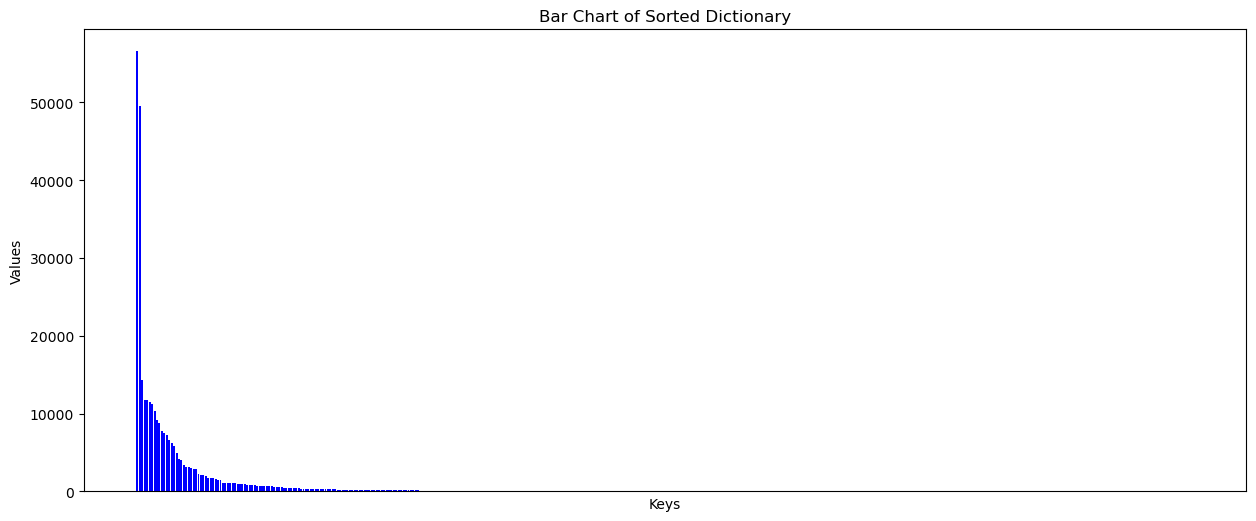

In [18]:
import matplotlib.pyplot as plt

# 示例字典
data = merged_dict

# 按值从大到小排序字典
sorted_data = dict(sorted(data.items(), key=lambda item: item[1], reverse=True))

# 提取排序后的键和值
keys = list(sorted_data.keys())
values = list(sorted_data.values())

# 创建柱状图
plt.figure(figsize=(15, 6))
plt.bar(keys, values, color='blue')
#plt.yscale('log')
# 添加标题和标签
plt.title('Bar Chart of Sorted Dictionary')
plt.xlabel('Keys')
plt.ylabel('Values')
plt.xticks([])

# 显示图表
plt.show()